# Classification and Generation with KDM

This notebook illustrates how to use [Kernel Density Matrices](https://github.com/fagonzalezo/kdm) for classification and generation.

In [ ]:
# Uncomment to install the required packages
# !pip install git+https://github.com/fagonzalezo/kdm.git@generative

  Cloning https://github.com/fagonzalezo/kdm.git (to revision generative) to /tmp/pip-req-build-984roi8h
  Running command git clone --filter=blob:none --quiet https://github.com/fagonzalezo/kdm.git /tmp/pip-req-build-984roi8h
  Running command git checkout -b generative --track origin/generative
  Switched to a new branch 'generative'
  Branch 'generative' set up to track remote branch 'generative' from 'origin'.
  Resolved https://github.com/fagonzalezo/kdm.git to commit 8670ea9c5f76c14ce14e65b475c4fd4a387c33ab
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for kdm: filename=kdm-1.0.0-py3-none-any.whl size=30886 sha256=8bb14560da37ad0ce3ebe16a174a80312dce649612e76a1f22d2904d6e318828
  Stored in directory: /tmp/pip-ephem-wheel-cache-37fs_dfo/wheels/04/16/53/e14d5346e39f04fd7f738b1af112407fb9e75401efce1e1d1e
Successfully built kdm


In [2]:
import numpy as np
from scipy.stats import norm
from scipy.stats import gaussian_kde

import os
os.environ["KERAS_BACKEND"] = "torch"

import keras
from keras import optimizers
from keras import losses
from keras import metrics
from keras.callbacks import ModelCheckpoint


from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

from kdm.models import KDMClassModel
import kdm

import matplotlib.pyplot as plt

In [3]:
# Create a 2 moons dataset
X, y = make_moons(n_samples=1000, noise=0.2, random_state=0)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)


<ipython-input-4-9f70f10eed74>:7: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(this_X[:, 0], this_X[:, 1],  c=color,


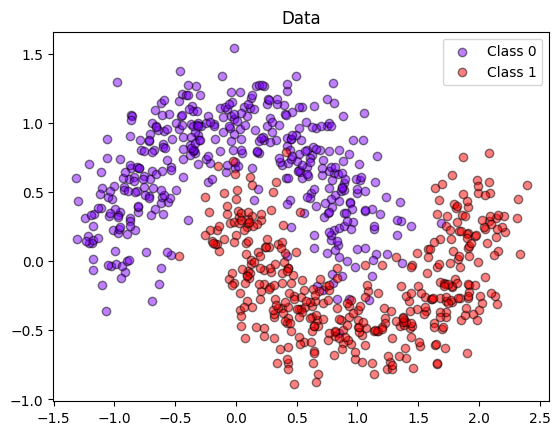

In [4]:
# Function to visualize a 2D dataset
def plot_data(X, y):
    y_unique = np.unique(y)
    colors = plt.cm.rainbow(np.linspace(0.0, 1.0, y_unique.size))
    for this_y, color in zip(y_unique, colors):
        this_X = X[y == this_y]
        plt.scatter(this_X[:, 0], this_X[:, 1],  c=color,
                    alpha=0.5, edgecolor='k',
                    label="Class %s" % this_y)
    plt.legend(loc="best")
    plt.title("Data")

# Function to visualize the decission surface of a classifier
def plot_decision_region(X, pred_fun):
    min_x = np.min(X[:, 0])
    max_x = np.max(X[:, 0])
    min_y = np.min(X[:, 1])
    max_y = np.max(X[:, 1])
    min_x = min_x - (max_x - min_x) * 0.05
    max_x = max_x + (max_x - min_x) * 0.05
    min_y = min_y - (max_y - min_y) * 0.05
    max_y = max_y + (max_y - min_y) * 0.05
    x_vals = np.linspace(min_x, max_x, 50)
    y_vals = np.linspace(min_y, max_y, 50)
    XX, YY = np.meshgrid(x_vals, y_vals)
    grid_r, grid_c = XX.shape
    vals = [[XX[i, j], YY[i, j]] for i in range(grid_r) for j in range(grid_c)]
    preds = pred_fun(np.array(vals))
    ZZ = np.reshape(preds, (grid_r, grid_c))
    print(np.min(preds), np.min(ZZ))
    plt.contourf(XX, YY, ZZ, 100, cmap = plt.cm.coolwarm, vmin= 0, vmax=1)
    plt.colorbar()
    CS = plt.contour(XX, YY, ZZ, 100, levels = [0.1*i for i in range(1,10)])
    plt.clabel(CS, inline=1, fontsize=10)
    plt.xlabel("x")
    plt.ylabel("y")

def gen_pred_fun(clf):
    def pred_fun(X):
        return clf.predict(X)[:, 1]
    return pred_fun

plot_data(X_train, y_train)

## 1 Generative classification two moons

The following example illustrates the use of the inference process using a generative classification model.

In general, the KDM classification model minimizes the following lost function:

$$
L(x^{(i)}, y^{(i)}) = - \sum_{k=1}^K 1(y^{(i)} == k) \log  P(y=k | x^{(i)}) - \alpha \log P(x^{(i)})
$$

Both $P(y=k | x^{(i)})$ and $P(x^{(i)})$ are predictions of the KDM model. $\alpha$ controls the importance of the generative component of the loss.

We use the KDMClassModel to train a shallow model that directly apply a KDM inference layer to the raw data. This class assumes a continuos distribution for the input data (i.e. it uses an RBF kernel) and a discrete distribution for the output data. The `generative` parameter corresponds to the $\alpha$ parameter controlling the importance of the generative term of the loss function.

In [5]:
encoded_size = 2
dim_y = 2
encoder = keras.Sequential([keras.layers.Identity()])
n_comp = 14

kdm_model = KDMClassModel(encoded_size=encoded_size,
                            dim_y=dim_y,
                            encoder=encoder,
                            n_comp=n_comp,
                            sigma=0.05,
                            generative=1.)

# train the classifier
kdm_model.compile(optimizer=optimizers.Adam(learning_rate=5e-3),
                    loss=keras.losses.sparse_categorical_crossentropy,
                    metrics=[metrics.sparse_categorical_accuracy])
kdm_model.predict(X_train[:10])
idx = np.random.randint(X_train.shape[0], size=n_comp)
kdm_model.init_components(X_train[idx],
                          np.eye(2)[y_train[idx]],
                          init_sigma=True)

print(f'Sigma: {kdm_model.kernel.sigma.numpy()}')
kdm_model.fit(X_train, y_train, epochs=25, batch_size=32, verbose=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 768ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Sigma: 0.5036155581474304
Epoch 1/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 6.2678 - sparse_categorical_accuracy: 0.9057
Epoch 2/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 6.1048 - sparse_categorical_accuracy: 0.9235
Epoch 3/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 5.9631 - sparse_categorical_accuracy: 0.9428
Epoch 4/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 5.8535 - sparse_categorical_accuracy: 0.9607
Epoch 5/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 5.7869 - sparse_categorical_accuracy: 0.9698
Epoch 6/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 5.8294 - sparse_categorical_accuracy: 0.9648
Epoch 7/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 5.7371 - sparse_categorical_accuracy: 0.9642
Epoch 8/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 5.7594 - sparse_categorical_accuracy: 0.9597
Epoch 9/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 5.7525

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
1.8568835e-09 1.8568835e-09
Test loss: 5.744178295135498
Test accuracy: 0.9850000143051147
Sigma: 0.2990204393863678


<ipython-input-4-9f70f10eed74>:7: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(this_X[:, 0], this_X[:, 1],  c=color,


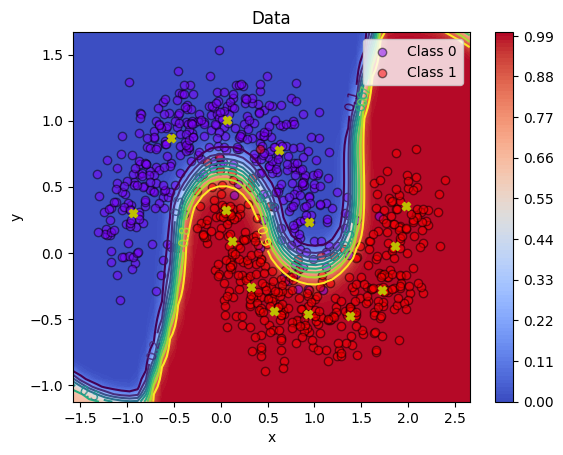

In [6]:
# Plot the decision region
plot_decision_region(X, gen_pred_fun(kdm_model))
plot_data(X_train, y_train)
# plot the prototypes
c_x = keras.ops.convert_to_numpy(kdm_model.kdm.c_x)
plt.scatter(c_x[:, 0], c_x[:, 1], c='y', marker='X')
# Evaluate the classifier
score = kdm_model.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])
print(f'Sigma: {kdm_model.kernel.sigma.numpy()}')

The above visualization shows the decision boundary of the classifier model along with the prototypes of the model. The prototypes are shown as yellow crosses. Because of the likelihood maximization, prototypes are distributed evenly in the input space to maximize the density of the input samples. The classification performance in on par with the discriminative model.

## MNIST example

An example using the mnist dataset. In addition to perform classification we will show how to perform generation.

In [7]:
# Create a dataset from mnist using tf
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()
X_train = X_train.astype('float32') / 255.
X_test = X_test.astype('float32') / 255.


# reshape the data to include a channel dimension
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)

# Partition the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.8, random_state=42)

def display_imgs(x, y=None):
    if not isinstance(x, (np.ndarray, np.generic)):
      x = np.array(x)
    plt.ioff()
    n = x.shape[0]
    fig, axs = plt.subplots(1, n, figsize=(n, 1))
    if y is not None:
      fig.suptitle(np.argmax(y, axis=1))
    for i in range(n):
      axs.flat[i].imshow(x[i].squeeze(), interpolation='none', cmap='gray')
      axs.flat[i].axis('off')
    plt.show()
    plt.close()
    plt.ion()


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


We define a deep encoder that will be used to map input images to a low-dimensional latent space.

In [8]:
kl = keras.layers

def create_encoder(input_shape, base_depth, encoded_size):
    encoder = keras.Sequential([
    kl.InputLayer(shape=input_shape),
    kl.Lambda(lambda x: x - 0.5),
    kl.Conv2D(base_depth, 5, strides=1,
                    padding='same', activation=keras.ops.leaky_relu),
    kl.Conv2D(base_depth, 5, strides=2,
                    padding='same', activation=keras.ops.leaky_relu),
    kl.Conv2D(2 * base_depth, 5, strides=1,
                    padding='same', activation=keras.ops.leaky_relu),
    kl.Conv2D(2 * base_depth, 5, strides=2,
                    padding='same', activation=keras.ops.leaky_relu),
    kl.Conv2D(4 * encoded_size, 7, strides=1,
                    padding='valid', activation=keras.ops.leaky_relu),
    kl.Dense(encoded_size, activation=None),
        #kl.LayerNormalization(),
    kl.Flatten(),
    ])
    return encoder

The classifier model (KDMClassModel) receives as input the encoder, and applies it before applying the KDM inference layer. First we train a discriminative classification model.

In [9]:
# Define the encoder
input_shape = (28, 28, 1)
base_depth = 32
encoded_size = 2
encoder = create_encoder(input_shape, base_depth, encoded_size)

# warm up the encoder
encoder_wmp = keras.Sequential([encoder,
                                  keras.layers.Dense(10, activation='softmax')])
encoder_wmp.predict(X_train[:10])
encoder_wmp.compile(optimizer=optimizers.Adam(learning_rate=1e-3),
                loss=losses.sparse_categorical_crossentropy,
                metrics=[metrics.sparse_categorical_accuracy])
encoder_wmp.fit(X_train, y_train, epochs=1, batch_size=64, verbose=1)
# Create a classifier model
dim_y = 10
n_comp = 64

kdm_mnist = KDMClassModel(encoded_size=encoded_size,
                            dim_y=dim_y,
                            encoder=encoder,
                            n_comp=n_comp,
                            sigma=0.1,
                            generative=0. # this value indicates a discriminative model
                            )

# initialize the prototypes using random samples from the training set
idx = np.random.randint(X_train.shape[0], size=n_comp)
kdm_mnist.init_components(X_train[idx], keras.ops.one_hot(y_train[idx], 10),
                          init_sigma=True, sigma_mult=1.0)

print(f'Sigma: {kdm_mnist.kernel.sigma.numpy()}')

# Compile the model
kdm_mnist.compile(optimizer=optimizers.Adam(learning_rate=1e-3),
                    loss=losses.sparse_categorical_crossentropy,
                    metrics=[metrics.sparse_categorical_accuracy])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 766ms/step
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 1.7542 - sparse_categorical_accuracy: 0.3055
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Sigma: 4.181840896606445


In [10]:
# Train the kdm discriminative model
kdm_mnist.fit(X_train, y_train, validation_data=(X_val[:1000], y_val[:1000]), epochs=10, batch_size=128, verbose=1)
print(f'Final Sigma: {kdm_mnist.kernel.sigma.numpy()}')


Epoch 1/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.6358 - sparse_categorical_accuracy: 0.8261 - val_loss: 0.4947 - val_sparse_categorical_accuracy: 0.8650
Epoch 2/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.3937 - sparse_categorical_accuracy: 0.8940 - val_loss: 0.3981 - val_sparse_categorical_accuracy: 0.9020
Epoch 3/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.3149 - sparse_categorical_accuracy: 0.9225 - val_loss: 0.4365 - val_sparse_categorical_accuracy: 0.9130
Epoch 4/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.2492 - sparse_categorical_accuracy: 0.9406 - val_loss: 0.3008 - val_sparse_categorical_accuracy: 0.9310
Epoch 5/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.2057 - sparse_categorical_accuracy: 0.9453 - val_loss: 0.2858 - val_sparse_categorical_accuracy: 0.9390
Epoch 6/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.1883 - sparse_categorical_accuracy: 0.9526 - val_loss: 0.3593 - val_sparse_categorical_accuracy: 0.9170
Epoch 7/10

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


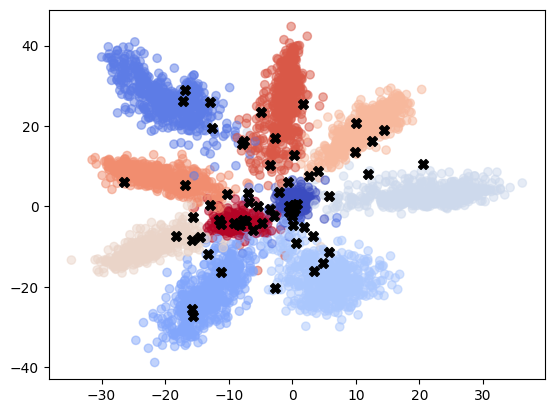

In [11]:
num_samples = 5000
encoded_samples = encoder.predict(X_train[:num_samples])
# Visualize the points in the feature space
plt.scatter(encoded_samples[:, 0], encoded_samples[:, 1], alpha=0.5, c=y_train[:num_samples], cmap=plt.cm.coolwarm)

prototypes = keras.ops.convert_to_numpy(kdm_mnist.kdm.c_x)
# plot the prototypes
plt.scatter(prototypes[:, 0], prototypes[:, 1], c='k', marker='X', s=50)
plt.show()

The figure above show training samples mapped to the latent space with different colors according to the class. The prototypes are shown as black crosses. Note that the prototypes do not cover all the areas of the different classes in the latent space, rather they are positioned to maximize the classification performance.

In [12]:
# Evaluate the classifier
score = kdm_mnist.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])
score = kdm_mnist.evaluate(X_train, y_train, verbose=0)
print('Train loss:', score[0])
print('Train accuracy:', score[1])
print(f'Sigma: {kdm_mnist.kernel.sigma.numpy()}')

Test loss: 0.20811128616333008
Test accuracy: 0.951200008392334
Train loss: 0.10620608180761337
Train accuracy: 0.9744166731834412
Sigma: 4.171075344085693


Now, we will train a generative model, based on the same encoder. The generative model is trained to maximize the likelihood of the input data, as well as minimize the classification loss. The goal is to obtain more representative prototypes, since the prototypes learned using the discriminative model are not representative of the data distribution, since them are optimized to maximize the classification accuracy.

In [15]:
n_comp = 128

kdm_mnist_gen = KDMClassModel(encoded_size=encoded_size,
                            dim_y=dim_y,
                            encoder=encoder,
                            n_comp=n_comp,
                            sigma=kdm_mnist.kernel.sigma.numpy(),
                            generative=1.0 # this value indicates a generative model
                            )

# initialize the prototypes using random samples from the training set
idx = np.random.randint(X_train.shape[0], size=n_comp)
kdm_mnist_gen.init_components(X_train[idx], keras.ops.one_hot(y_train[idx], 10),
                          init_sigma=False)

print(f'Sigma: {kdm_mnist_gen.kernel.sigma.numpy()}')

# Compile the model
kdm_mnist_gen.compile(optimizer=optimizers.Adam(learning_rate=1e-3),
                    loss=losses.sparse_categorical_crossentropy,
                    metrics=[metrics.sparse_categorical_accuracy])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Sigma: 4.171075344085693


In [16]:
# Train the kdm generative model
kdm_mnist_gen.fit(X_train, y_train, validation_data=(X_val[:1000], y_val[:1000]), epochs=20, batch_size=128, verbose=1)
print(f'Final Sigma: {kdm_mnist_gen.kernel.sigma.numpy()}')


Epoch 1/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 11.7552 - sparse_categorical_accuracy: 0.9653 - val_loss: 11.8574 - val_sparse_categorical_accuracy: 0.9380
Epoch 2/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 11.7000 - sparse_categorical_accuracy: 0.9660 - val_loss: 11.8404 - val_sparse_categorical_accuracy: 0.9380
Epoch 3/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 11.7158 - sparse_categorical_accuracy: 0.9642 - val_loss: 11.8229 - val_sparse_categorical_accuracy: 0.9380
Epoch 4/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 11.6807 - sparse_categorical_accuracy: 0.9649 - val_loss: 11.8097 - val_sparse_categorical_accuracy: 0.9380
Epoch 5/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 11.6774 - sparse_categorical_accuracy: 0.9669 - val_loss: 11.8004 - val_sparse_categorical_accuracy: 0.9380
Epoch 6/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 11.6432 - sparse_categorical_accuracy: 0.9682 - val_loss: 11.7815 - val_sparse_categorical_accuracy: 0.938

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


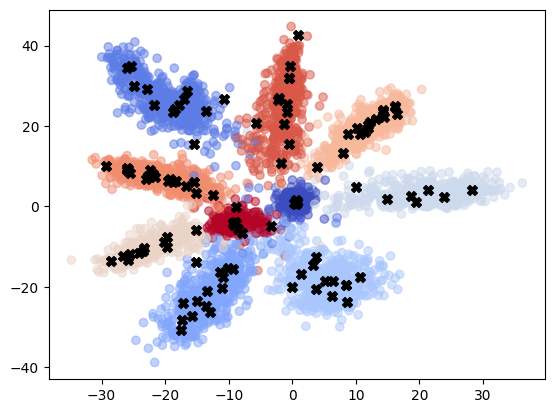

In [17]:
num_samples = 5000
encoded_samples = encoder.predict(X_train[:num_samples])
# Visualize the points in the feature space
plt.scatter(encoded_samples[:, 0], encoded_samples[:, 1], alpha=0.5, c=y_train[:num_samples], cmap=plt.cm.coolwarm)

prototypes = keras.ops.convert_to_numpy(kdm_mnist_gen.kdm.c_x)
# plot the prototypes
plt.scatter(prototypes[:, 0], prototypes[:, 1], c='k', marker='X', s=50)
plt.show()

In [18]:
# Evaluate the classifier
score = kdm_mnist_gen.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])
score = kdm_mnist_gen.evaluate(X_train, y_train, verbose=0)
print('Train loss:', score[0])
print('Train accuracy:', score[1])
print(f'Sigma: {kdm_mnist_gen.kernel.sigma.numpy()}')

Test loss: 11.737582206726074
Test accuracy: 0.9484000205993652
Train loss: 11.495857238769531
Train accuracy: 0.9721666574478149
Sigma: 2.941587209701538


## Generator model

We can build a generator taking advantage of the symmetry of the KDM layer. Basically we change the role of the x-prototypes and the y-prototypes. The entry to the model will be a 10D vector that represents probability distribution of the digits to generate . The output of the KDM layer will be a probability distribution on the latent space. We can sample from this distribution to generate new samples that we will decode to obtain the generated digit. First we will train a decoder.

In [19]:

def create_decoder(base_depth, encoded_size):
    decoder = keras.Sequential([
        kl.InputLayer(shape=[encoded_size]),
        kl.Reshape([1, 1, encoded_size]),
        kl.Conv2DTranspose(2 * base_depth, 6, strides=1,
                            padding='valid', activation=keras.ops.leaky_relu),
        kl.Conv2DTranspose(2 * base_depth, 5, strides=1,
                            padding='same', activation=keras.ops.leaky_relu),
        kl.Conv2DTranspose(2 * base_depth, 5, dilation_rate=2,
                            padding='valid', activation=keras.ops.leaky_relu),
        kl.Conv2DTranspose(base_depth, 5, strides=1,
                            padding='same', activation=keras.ops.leaky_relu),
        kl.Conv2DTranspose(base_depth, 5, dilation_rate=2,
                            padding='valid', activation=keras.ops.leaky_relu),
        kl.Conv2DTranspose(base_depth, 4, dilation_rate=2,
                            padding='valid', activation=keras.ops.leaky_relu),
        kl.Conv2D(filters=1, kernel_size=5, strides=1,
                    padding='same', activation=None),
    ])
    return decoder

decoder = create_decoder(base_depth, encoded_size)
inputs = keras.layers.Input(shape=input_shape)
ae_model = keras.Sequential([inputs,
                            encoder,
                            decoder
                           ])
encoder.trainable = False

ae_model.compile(optimizer=optimizers.Adam(learning_rate=1e-4),
            loss=losses.BinaryCrossentropy(from_logits=True))

ae_model.fit(X_train, X_train, epochs=20, batch_size=128, verbose=1)

Epoch 1/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.5984
Epoch 2/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.2984
Epoch 3/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.2786
Epoch 4/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.2656
Epoch 5/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.2592
Epoch 6/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.2527
Epoch 7/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.2472
Epoch 8/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.2448
Epoch 9/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.2409
Epoch 10/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.2383
Epoch 11/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.2352
Epoch 12/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.2340
Epoch 13/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.2322
Epoch 14/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.2287
Epoch 15/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.2279
Epoc

Let's plot some generated digits. The digits generated from the autoencoder are fuzzy because of the small dimension of the latent space.

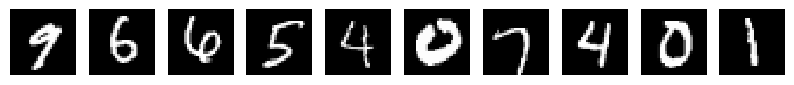

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


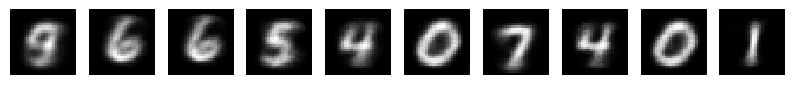

In [20]:
display_imgs(X_test[20:30])
prediction = ae_model.predict(X_test[20:30])

prediction = keras.ops.convert_to_numpy(
    keras.ops.sigmoid(prediction))
display_imgs(prediction)

Now we define the generator model. It receives a 10D vector that represents the probability distribution of the digits to generate. The output of the KDM layer is a probability distribution on the latent space. We can sample from this distribution to generate new samples that we will decode to obtain the generated digit.

In [21]:
from keras import Model
from keras.layers import Input
from kdm.layers import CosineKernelLayer, KDMLayer

def create_generator_model(clf_model):
        inputs_gen = Input(shape=(10,))
        kernel_gen = CosineKernelLayer()
        kdm_gen = KDMLayer(kernel=kernel_gen,
                                   dim_x=10,
                                   dim_y=clf_model.encoded_size,
                                   n_comp=clf_model.n_comp)
        kdm_gen.c_x.assign(clf_model.kdm.c_y)
        kdm_gen.c_y.assign(clf_model.kdm.c_x)
        kdm_gen.c_w.assign(clf_model.kdm.c_w)
        rho_y_gen = kdm.utils.pure2dm(inputs_gen)
        rho_x_gen = kdm_gen(rho_y_gen)
        gen_model = Model(inputs_gen, rho_x_gen)
        return gen_model

gen_model = create_generator_model(kdm_mnist_gen)
gen_model.compile()

In [22]:
import tensorflow as tf

import tensorflow_probability as tfp
tfd = tfp.distributions

def dm2distrib(dm, sigma):
    '''
    Creates a Gaussian mixture distribution from the components of a density
    matrix with an RBF kernel
    Arguments:
     dm: tensor of shape (bs, n, d + 1)
     sigma: sigma parameter of the RBF kernel
    Returns:
     gm: mixture of Gaussian distribution with shape (bs, )
    '''
    w, v = kdm.utils.dm2comp(dm)
    gm = tfd.MixtureSameFamily(reparameterize=True,
            mixture_distribution=tfd.Categorical(
                                    probs=w),
            components_distribution=tfd.Independent( tfd.Normal(
                    loc=v,  # component 2
                    scale=sigma / np.sqrt(2.)),
                    reinterpreted_batch_ndims=1))
    return gm

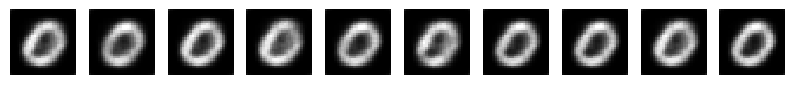

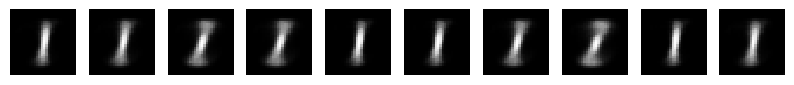

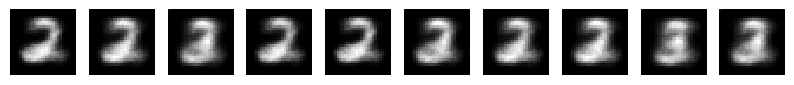

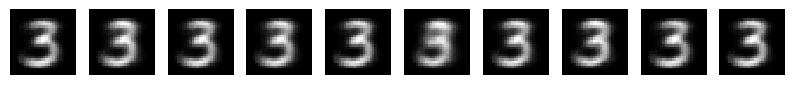

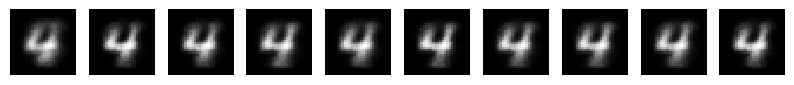

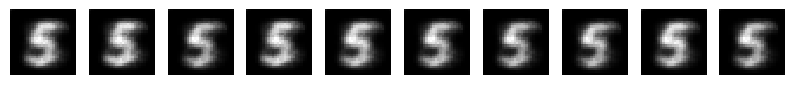

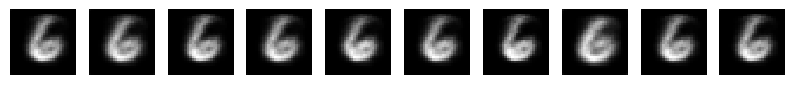

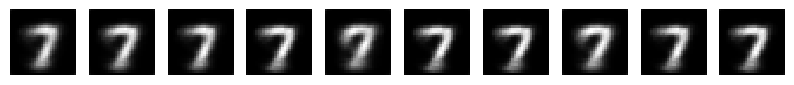

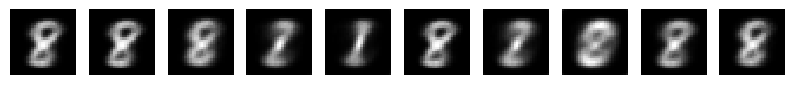

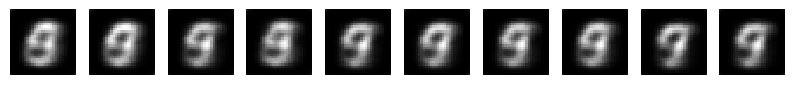

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


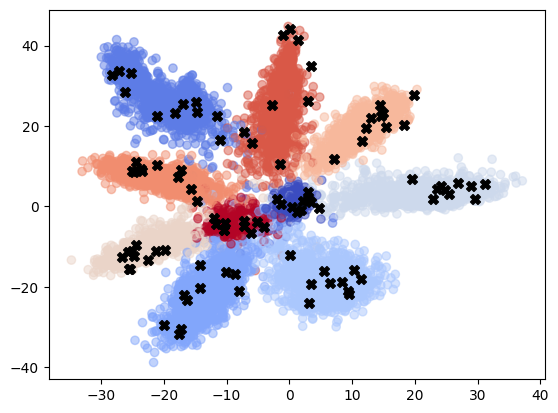

In [23]:
# Generate a set of distributions from the model for each digit
rho_y = keras.ops.convert_to_numpy(
    gen_model(keras.ops.eye(10)))
rho_y = np.float64(rho_y)

sigma = keras.ops.convert_to_numpy(kdm_mnist_gen.kernel.sigma)
sigma = np.float64(sigma)

distribs = dm2distrib(rho_y, sigma=sigma)
# Sample from the distributions
samples = []
for i in range(10):
    sample = distribs[i].sample(10).numpy()
    samples.append(sample)
    # Show the decoded images
    decoded_imgs = decoder(sample)
    decoded_imgs = keras.ops.convert_to_numpy(
        keras.ops.sigmoid(decoded_imgs))
    display_imgs(decoded_imgs)

# plot the samples in the feature space
num_train_samples = 10000
encoded_train = keras.ops.convert_to_numpy(encoder.predict(X_train[:num_train_samples]))

plt.scatter(encoded_train[:, 0], encoded_train[:, 1], alpha=0.5,
            c=y_train[:num_train_samples], cmap=plt.cm.coolwarm)

# plot the prototypes
samples = np.concatenate(samples)
plt.scatter(samples[:, 0], samples[:, 1], c='k', marker='X', s=50)
plt.show()


Now we will generate digits from a label distribution that is a mixture of two digits. We will generate digits that are a mixture of 0 and 1.

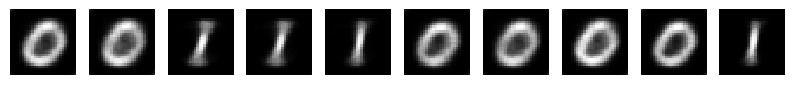

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


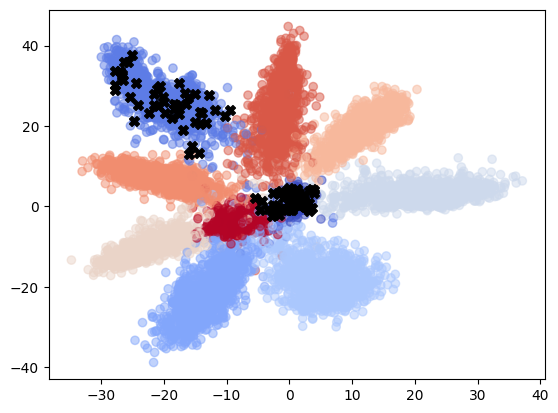

In [24]:
# Generate a set of distributions from the model for each digit
y_distrib = np.zeros((1,10))
y_distrib[0, 0] = 1 / np.sqrt(2)
y_distrib[0, 1] = 1 / np.sqrt(2)
rho_y = keras.ops.convert_to_numpy(
    gen_model(y_distrib))
rho_y = np.float64(rho_y)
x_distrib = dm2distrib(rho_y, sigma=sigma)[0]
# Sample from the distributions
sample = x_distrib.sample(100).numpy()
# Show the decoded images
decoded_imgs = decoder(sample[:10])
decoded_imgs = keras.ops.convert_to_numpy(
        keras.ops.sigmoid(decoded_imgs))
display_imgs(decoded_imgs)

# plot the samples in the feature space
num_train_samples = 10000
encoded_train = keras.ops.convert_to_numpy(encoder.predict(X_train[:num_train_samples]))

plt.scatter(encoded_train[:, 0], encoded_train[:, 1], alpha=0.5,
            c=y_train[:num_train_samples], cmap=plt.cm.coolwarm)

# plot the prototypes
plt.scatter(sample[:, 0], sample[:, 1], c='k', marker='X', s=50)
plt.show()
